In [10]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [ ]:
log_file = "PC_vulkan_MLUPS.log" # log file path

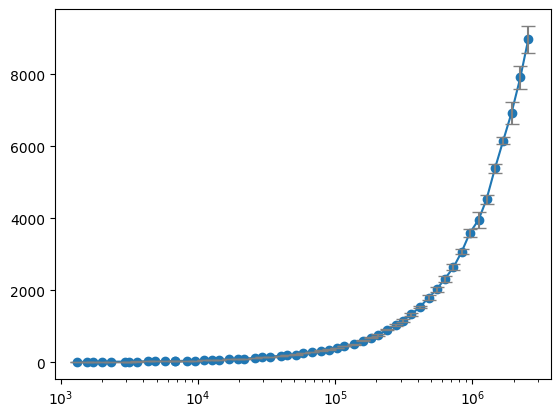

In [ ]:
n_lattice_list = []
macro_MLUPS_list = [] # 总计算量/总时间
init_time_list = []
compile_time_list = []
avg_MLUPS_list = [] # 每次计算量/每次时间 mean
std_MLUPS_list = [] # 每次计算量/每次时间 std
with open(log_file, 'r') as f:
    line = f.readline() # 第一行忽略
    line = f.readline()
    while line: 
        line2 = f.readline() # n lattice
        line3 = f.readline() # MLUPS
        line4 = f.readline() # avg time
        line5 = f.readline() # compile time
        line6 = f.readline() # init time
        line7 = f.readline() # v test
        line8 = f.readline() # execution time list
        line9 = f.readline() # -----
        line = f.readline() # EOF or next arch
        nLattice = int(line2)
        n_lattice_list.append(nLattice)
        macro_MLUPS_list.append(float(line3))
        compile_time_list.append(float(line5))
        init_time_list.append(float(line6))
        exec_time_list = [float(t) for t in line8[1:-2].split(',') if t.strip()!='']
        exec_time_array = np.array(exec_time_list)
        MLUPS_array = nLattice*10000 / (exec_time_array * 1e6)
        avg_MLUPS_list.append(np.mean(MLUPS_array))
        std_MLUPS_list.append(np.std(MLUPS_array))


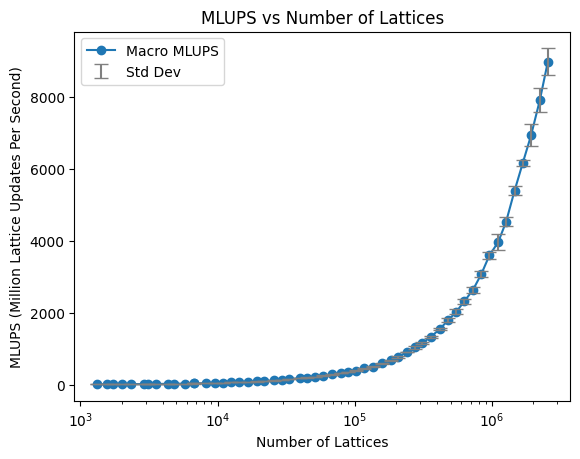

In [19]:
plt.plot(n_lattice_list, avg_MLUPS_list, 'o-', label='Macro MLUPS')
# plt.plot(n_lattice_list, macro_MLUPS_list, 's--', label='Avg MLUPS')
plt.errorbar(n_lattice_list, avg_MLUPS_list, yerr=std_MLUPS_list, fmt='none', ecolor='gray', capsize=5, label='Std Dev')
plt.xscale('log')
plt.xlabel('Number of Lattices')
plt.ylabel('MLUPS (Million Lattice Updates Per Second)')
plt.title('MLUPS vs Number of Lattices')
plt.legend()
plt.show()

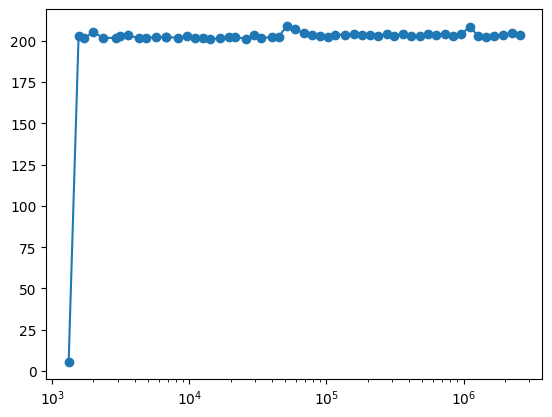

In [18]:
plt.plot(n_lattice_list, compile_time_list, 'o-', label='Compile Time')
plt.xscale('log')
plt.show()